# Retinal Images for Vessel Extraction
**Module:** CO4 - Imaging for the Life Science FS26

**Lecturers:** Dr. sc. ETH Andreas Hock and Dr. Norman Juchler

**Author:** Luana da Silva do Aido - dasillua@students.zhaw.ch

## 1. Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os
import pandas as pd
from PIL import Image
from skimage.filters import frangi, gaussian, sobel
from skimage.morphology import remove_small_objects, erosion, disk
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, jaccard_score

### 1.1 Load Images

In [2]:
def load_images_from_folder(folder_path):
    """
    Loads all images from a given folder and converts them to RGB.

    Args:
        folder_path (str): Path to the folder containing images.

    Returns:
        dict: Dictionary with filename as key and RGB image (np.ndarray) as value.
    """
    images = {}
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('.tif') or filename.endswith('.gif') or filename.endswith('.png'):
            img = cv.imread(os.path.join(folder_path, filename))
            img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            images[filename] = img_rgb
    return images


def load_manual_segmentations(folder_path):
    """
    Loads manually created binary segmentation masks using PIL.
    PIL is used instead of cv2 to correctly handle TIF orientation from Fiji.

    Args:
        folder_path (str): Path to folder with manual segmentation files.

    Returns:
        dict: Dictionary with filename as key and binary mask (np.ndarray) as value.
    """
    masks = {}
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('.png') or filename.endswith('.tif'):
            img = np.array(Image.open(os.path.join(folder_path, filename)))
            if len(img.shape) == 3:
                img = img[:, :, 0]
            masks[filename] = (img > 127).astype(np.uint8)
    return masks


# Load all images
train_images = load_images_from_folder('DRIVE/training/images/')
test_images = load_images_from_folder('DRIVE/test/images')

# Load manual segmentations (10 images segmented in Fiji)
manual_segs = load_manual_segmentations('DRIVE/training/segmentation_images')

print(f'Training images: {len(train_images)}')
print(f'Test images: {len(test_images)}')
print(f'Manual segmentations: {len(manual_segs)}')

Training images: 20
Test images: 20
Manual segmentations: 10


### 1.2 Preprocess Images

In [3]:
def preprocess_image(img):
    """
    Preprocesses a retinal image for vessel segmentation.
    Steps:
    1. Extract green channel
    2. Apply CLAHE for contrast enhancement
    3. Normalize to [0, 1]

    Args:
        img (np.ndarray): RGB image of shape (H, W, 3).

    Returns:
        np.ndarray: Preprocessed grayscale image normalized to [0, 1].
    """
    # 1. Green channel (best contrast for vessels)
    green = img[:, :, 1]

    # 2. CLAHE for local contrast enhancement
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(green)

    # 3. Normalize to [0, 1]
    normalized = clahe_img / 255.0

    return normalized


def apply_mask(preprocessed_img, mask_path):
    """
    Applies a binary GIF mask to a preprocessed image to isolate the retinal region.

    Args:
        preprocessed_img (np.ndarray): Grayscale image normalized to [0, 1].
        mask_path (str): Path to the GIF mask file.

    Returns:
        np.ndarray: Masked image with background set to 0.
    """
    mask = np.array(Image.open(mask_path)) / 255.0
    return preprocessed_img * mask


# Only preprocess the 10 images that have manual segmentations
train_images_filtered = {name: train_images[name] for name in manual_segs.keys()}
train_preprocessed_filtered = {name: preprocess_image(img) for name, img in train_images_filtered.items()}

# Apply masks
train_masked_filtered = {}
for name in manual_segs.keys():
    mask_name = name.replace('.tif', '_mask.gif')
    mask_path = os.path.join('DRIVE/training/mask', mask_name)
    train_masked_filtered[name] = apply_mask(train_preprocessed_filtered[name], mask_path)

print(f'Preprocessed and masked: {len(train_masked_filtered)} images')

Preprocessed and masked: 10 images


### 1.3 Visualize Preprocessing

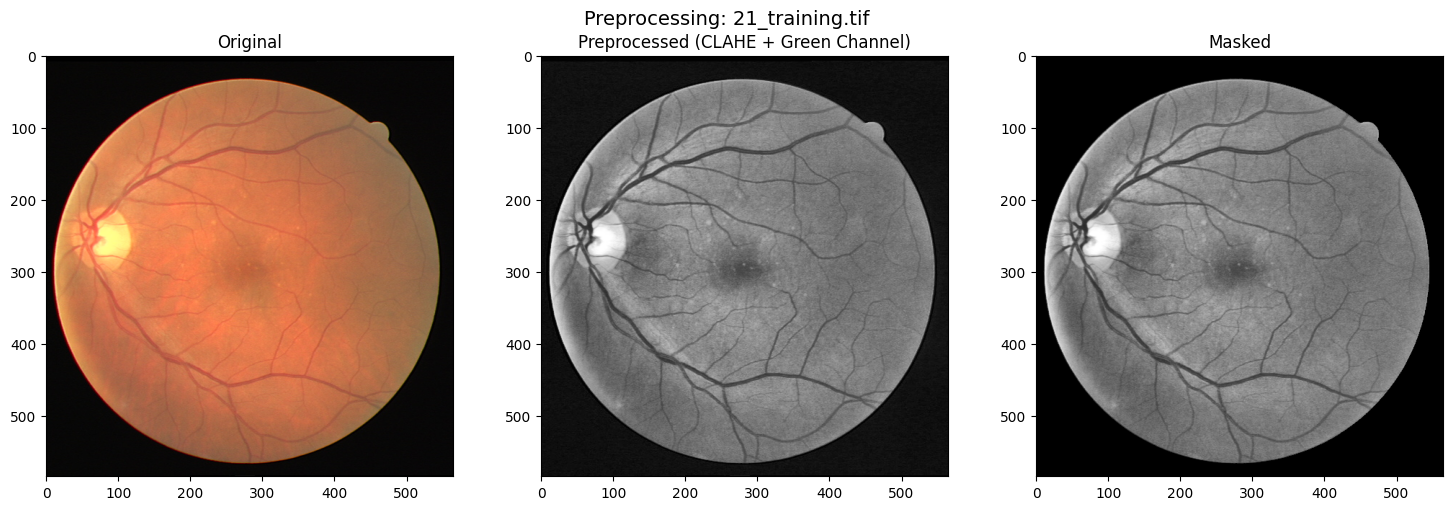

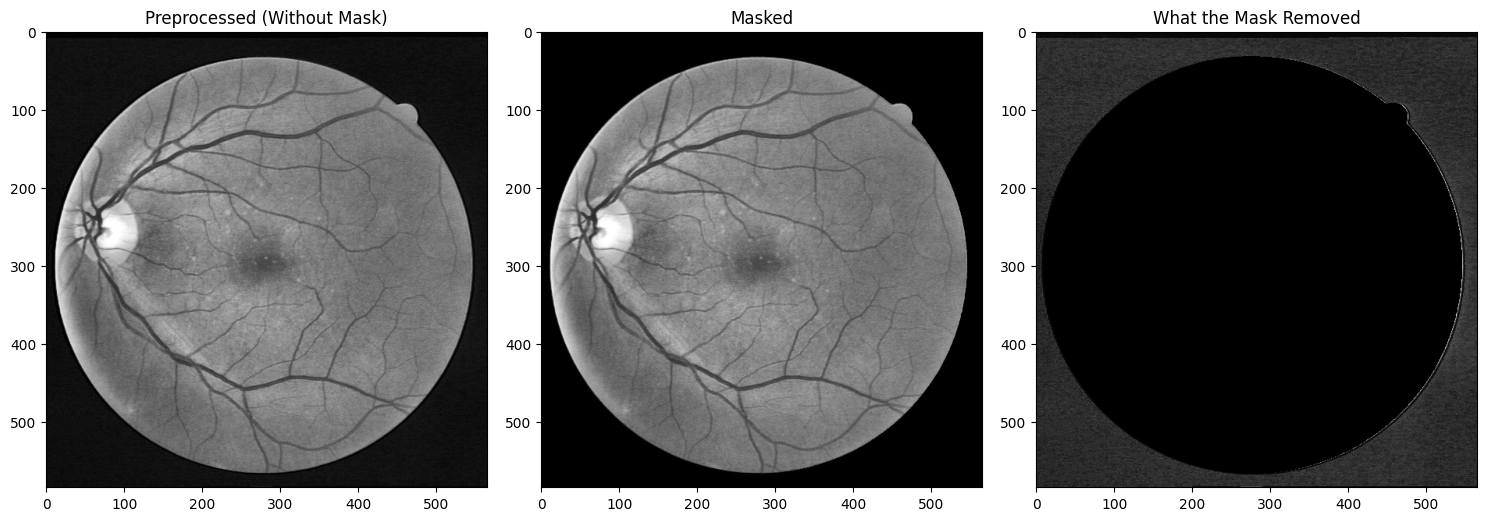

In [4]:
first_name = list(train_masked_filtered.keys())[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_images_filtered[first_name])
axes[0].set_title('Original')
axes[1].imshow(train_preprocessed_filtered[first_name], cmap='gray')
axes[1].set_title('Preprocessed (CLAHE + Green Channel)')
axes[2].imshow(train_masked_filtered[first_name], cmap='gray')
axes[2].set_title('Masked')
plt.suptitle(f'Preprocessing: {first_name}', fontsize=14)
plt.tight_layout()
plt.savefig('DRIVE/training/preprocessing_example.png', dpi=150)
plt.show()

# Show what the mask removed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_preprocessed_filtered[first_name], cmap='gray')
axes[0].set_title('Preprocessed (Without Mask)')
axes[1].imshow(train_masked_filtered[first_name], cmap='gray')
axes[1].set_title('Masked')
diff = train_preprocessed_filtered[first_name] - train_masked_filtered[first_name]
axes[2].imshow(diff, cmap='gray')
axes[2].set_title('What the Mask Removed')
plt.tight_layout()
plt.show()

### Documentation

## Ziel
Das Ziel des Preprocessings ist es, die Retinalbilder so vorzubereiten,
dass die Blutgefässe möglichst gut sichtbar sind und die automatische
Segmentation erleichtert wird.

## Schritte

### 1. Bilder laden
Die Bilder des DRIVE Datasets werden aus den Ordnern `training/images` 
und `test/images` geladen und in RGB konvertiert. Das Dataset enthält 
40 Retinalbilder von diabetischen Patienten im PNG/TIF Format.

### 2. Green Channel Extraktion
Aus dem RGB-Bild wird nur der grüne Kanal extrahiert. Der Grund dafür 
ist, dass Blut grünes Licht stärker absorbiert als rotes oder blaues 
Licht. Das bedeutet, dass Blutgefässe im grünen Kanal am dunkelsten 
erscheinen und damit den stärksten Kontrast zum umliegenden Gewebe 
zeigen. Das Bild wird dadurch zu einem Graustufenbild (ein Kanal statt 
drei), was die weitere Verarbeitung vereinfacht.

### 3. CLAHE (Contrast Limited Adaptive Histogram Equalization)
CLAHE ist eine Methode zur lokalen Kontrastverbesserung. Im Gegensatz zur 
normalen Histogrammausgleichung arbeitet CLAHE auf kleinen Bildregionen (tiles), 
was besonders bei Retinalbildern mit ungleichmässiger Beleuchtung vorteilhaft ist. 
Die Parameter wurden auf `clipLimit=2.0` und `tileGridSize=(8,8)` gesetzt.

### 4. Normalisierung
Das Bild wird auf den Wertebereich [0, 1] normalisiert, was für die 
weiteren Verarbeitungsschritte und die automatische Segmentation erforderlich ist.

### 5. Maskenanwendung
Das DRIVE Dataset enthält binäre Masken im GIF Format, die den Augapfel 
vom schwarzen Hintergrund trennen. Die Maske wird mit PIL geladen und auf das 
preprocesste Bild multipliziert, sodass nur innerhalb des Augapfels gearbeitet wird.

## 2. Manual Segmentation

10 images were manually segmented using Fiji (ImageJ):

1. Open original image: **File → Open**
2. Convert to 8-bit: **Image → Type → 8-bit**
3. Adjust contrast: **Image → Adjust → Brightness/Contrast**
4. Draw vessels using the **Pencil Tool**
5. Binarize: **Image → Adjust → Threshold → Apply**
6. Save as TIF: **File → Save As → Tiff**

The resulting binary images have white pixels (255) for vessels and black pixels (0) for background.

## 3. Automatic Segmentation

### 3.1 Classical Method: Frangi Filter

In [13]:
def frangi_segmentation(preprocessed_img, mask_path, threshold=0.05):
    """
    Applies Frangi filter to detect vessel-like tubular structures.
    The Frangi filter enhances elongated structures by analyzing the
    eigenvalues of the Hessian matrix at each pixel. Small noise objects
    are removed and the retinal mask is applied to avoid border artifacts.

    Args:
        preprocessed_img (np.ndarray): Grayscale image normalized to [0, 1].
        mask_path (str): Path to the GIF mask file.
        threshold (float): Threshold to binarize the Frangi response.

    Returns:
        tuple: (binary mask np.ndarray, raw Frangi response np.ndarray)
    """
    # Apply Frangi filter
    vessel_enhanced = frangi(preprocessed_img)
    vessel_enhanced = vessel_enhanced / vessel_enhanced.max()

    # Binarize
    binary = (vessel_enhanced > threshold).astype(bool)

    # Remove small noise objects
    binary = remove_small_objects(binary, min_size=50)

    # Apply eroded mask to remove ring artifact at border
    mask = np.array(Image.open(mask_path)) / 255.0
    mask_eroded = erosion(mask, disk(5))
    binary = binary * mask_eroded

    return binary.astype(np.uint8), vessel_enhanced


# Apply Frangi to all 10 filtered images
train_frangi_filtered = {}
for name in manual_segs.keys():
    mask_name = name.replace('.tif', '_mask.gif')
    mask_path = os.path.join('DRIVE/training/mask', mask_name)
    binary, _ = frangi_segmentation(train_masked_filtered[name], mask_path)
    train_frangi_filtered[name] = binary
    print(f'Frangi done: {name}')

print('Fertig!')

/var/folders/ll/pyzw9bhn42nch1zcwqb9gr4c0000gn/T/ipykernel_15534/52101048.py:24: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=50)


Frangi done: 21_training.tif
Frangi done: 22_training.tif
Frangi done: 24_training.tif
Frangi done: 25_training.tif
Frangi done: 26_training.tif
Frangi done: 27_training.tif
Frangi done: 28_training.tif
Frangi done: 29_training.tif
Frangi done: 35_training.tif
Frangi done: 39_training.tif
Fertig!


/var/folders/ll/pyzw9bhn42nch1zcwqb9gr4c0000gn/T/ipykernel_15534/52101048.py:24: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=50)


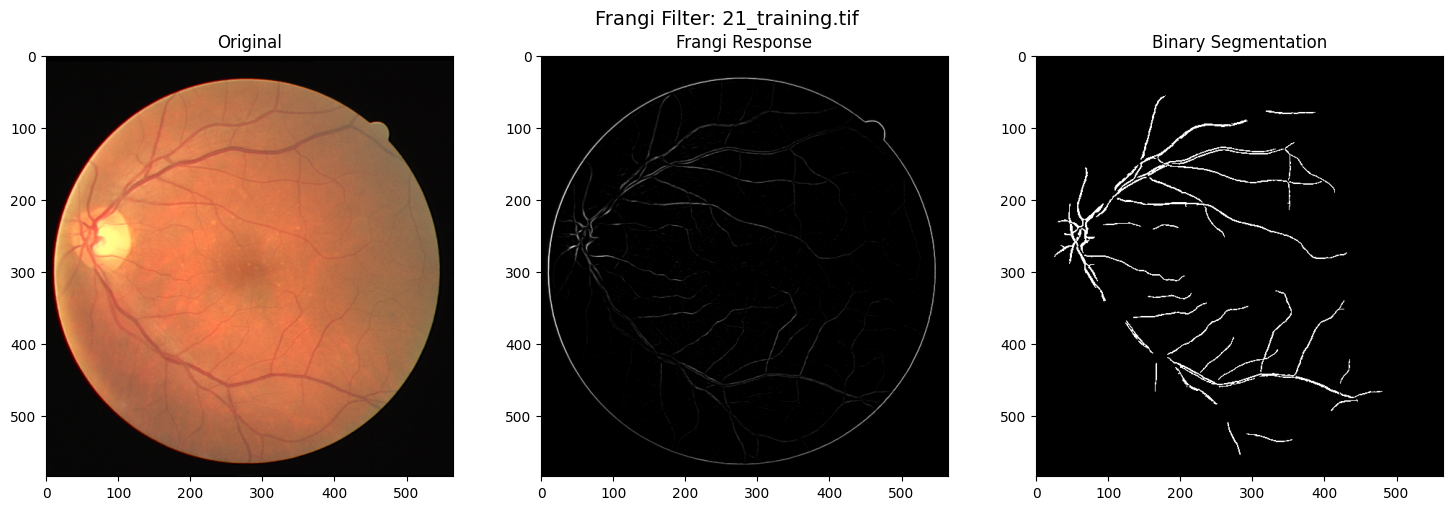

In [14]:
# Visualize Frangi result on first image
_, enhanced = frangi_segmentation(
    train_masked_filtered[first_name],
    os.path.join('DRIVE/training/mask', first_name.replace('.tif', '_mask.gif'))
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_images_filtered[first_name])
axes[0].set_title('Original')
axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('Frangi Response')
axes[2].imshow(train_frangi_filtered[first_name], cmap='gray')
axes[2].set_title('Binary Segmentation')
plt.suptitle(f'Frangi Filter: {first_name}', fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 ML Method: Random Forest

In [7]:
def extract_features(img):
    """
    Extracts pixel-wise features from a preprocessed retinal image.
    Features include raw intensity, Gaussian smoothing at multiple scales,
    Sobel edge detection, and Frangi vessel response.

    Args:
        img (np.ndarray): Grayscale image normalized to [0, 1].

    Returns:
        np.ndarray: Feature matrix of shape (n_pixels, n_features).
    """
    features = []

    # 1. Raw intensity
    features.append(img.flatten())

    # 2. Gaussian blur at multiple scales
    for sigma in [1, 2, 4]:
        features.append(gaussian(img, sigma=sigma).flatten())

    # 3. Sobel edges
    features.append(sobel(img).flatten())

    # 4. Frangi response
    frangi_response = frangi(img)
    frangi_response = frangi_response / (frangi_response.max() + 1e-8)
    features.append(frangi_response.flatten())

    return np.stack(features, axis=1)


def prepare_training_data(masked_images, manual_segs):
    """
    Prepares pixel-wise training data for the Random Forest classifier.
    Extracts features from each image and uses manual segmentations as labels.
    Only uses images that have a corresponding manual segmentation.

    Args:
        masked_images (dict): Preprocessed and masked images (only the 10 filtered).
        manual_segs (dict): Binary manual segmentation masks.

    Returns:
        tuple: Feature matrix X and label vector y for training.
    """
    X_list = []
    y_list = []

    for name in manual_segs.keys():
        img = masked_images[name]
        mask = manual_segs[name]
        X_list.append(extract_features(img))
        y_list.append(mask.flatten())

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    print(f'Training samples: {X.shape[0]}, Features: {X.shape[1]}')
    return X, y


def train_random_forest(X_train, y_train):
    """
    Trains a Random Forest classifier on pixel-wise features.

    Args:
        X_train (np.ndarray): Feature matrix of shape (n_pixels, n_features).
        y_train (np.ndarray): Binary label vector of shape (n_pixels,).

    Returns:
        RandomForestClassifier: Trained classifier.
    """
    print('Training Random Forest...')
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    print('Training done!')
    return rf


def predict_random_forest(rf_model, img):
    """
    Predicts vessel segmentation using the trained Random Forest classifier.

    Args:
        rf_model (RandomForestClassifier): Trained classifier.
        img (np.ndarray): Preprocessed and masked image normalized to [0, 1].

    Returns:
        np.ndarray: Binary segmentation mask of shape (H, W).
    """
    features = extract_features(img)
    prediction = rf_model.predict(features)
    return prediction.reshape(img.shape)


# Train
X_train, y_train = prepare_training_data(train_masked_filtered, manual_segs)
rf_model = train_random_forest(X_train, y_train)

Training samples: 3299600, Features: 6
Training Random Forest...
Training done!


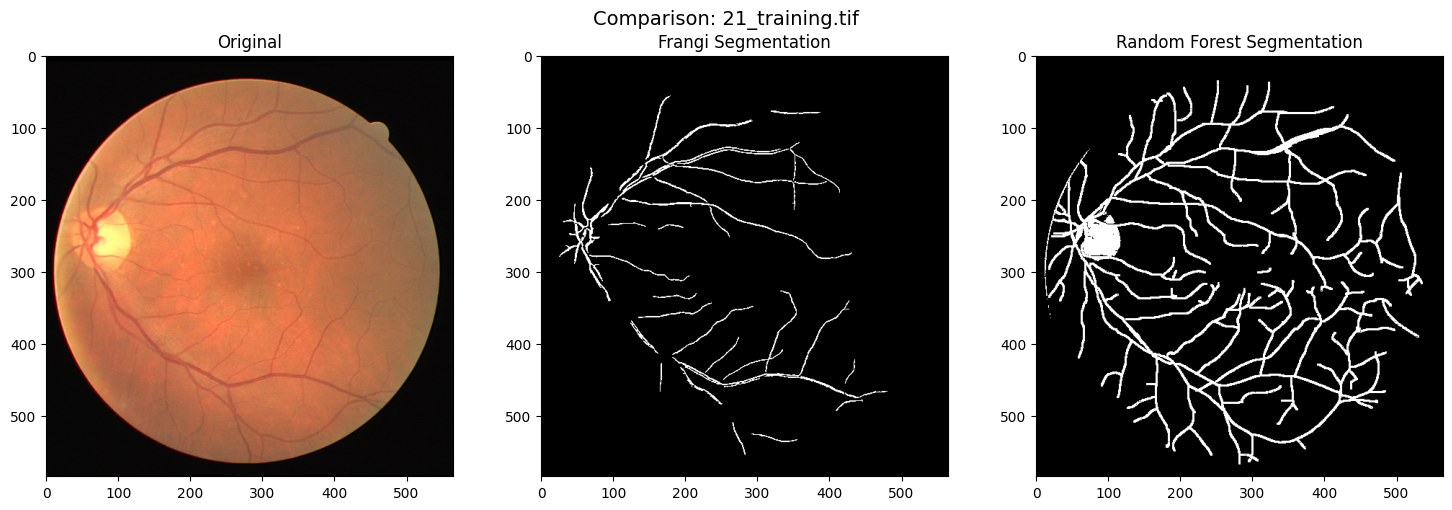

In [15]:
# Visualize RF result vs Frangi on first image
rf_binary = predict_random_forest(rf_model, train_masked_filtered[first_name])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_images_filtered[first_name])
axes[0].set_title('Original')
axes[1].imshow(train_frangi_filtered[first_name], cmap='gray')
axes[1].set_title('Frangi Segmentation')
axes[2].imshow(rf_binary, cmap='gray')
axes[2].set_title('Random Forest Segmentation')
plt.suptitle(f'Comparison: {first_name}', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Evaluation

Both methods are evaluated against the manual segmentations using:
- **Dice Score (F1)**: Main metric for binary segmentation — measures overlap between predicted and manual mask
- **Jaccard Score (IoU)**: Similar to Dice but stricter

In [16]:
def evaluate_segmentation(predicted, ground_truth):
    """
    Evaluates a binary segmentation mask against a ground truth mask.
    Computes Dice (F1) and Jaccard (IoU) scores pixel-wise.

    Args:
        predicted (np.ndarray): Binary predicted segmentation mask.
        ground_truth (np.ndarray): Binary ground truth segmentation mask.

    Returns:
        dict: Dictionary with 'dice' and 'jaccard' scores.
    """
    pred_flat = predicted.flatten()
    gt_flat = ground_truth.flatten()
    dice = f1_score(gt_flat, pred_flat, zero_division=0)
    jaccard = jaccard_score(gt_flat, pred_flat, zero_division=0)
    return {'dice': dice, 'jaccard': jaccard}


# Compute scores for all 10 images
results_data = []

for name in manual_segs.keys():
    gt = manual_segs[name]
    frangi_scores = evaluate_segmentation(train_frangi_filtered[name], gt)
    rf_scores = evaluate_segmentation(predict_random_forest(rf_model, train_masked_filtered[name]), gt)

    results_data.append({
        'Image': name.replace('_training.tif', ''),
        'Frangi Dice': round(frangi_scores['dice'], 3),
        'Frangi Jaccard': round(frangi_scores['jaccard'], 3),
        'RF Dice': round(rf_scores['dice'], 3),
        'RF Jaccard': round(rf_scores['jaccard'], 3),
    })

df = pd.DataFrame(results_data)

# Add mean row
mean_row = {
    'Image': 'MEAN',
    'Frangi Dice': round(df['Frangi Dice'].mean(), 3),
    'Frangi Jaccard': round(df['Frangi Jaccard'].mean(), 3),
    'RF Dice': round(df['RF Dice'].mean(), 3),
    'RF Jaccard': round(df['RF Jaccard'].mean(), 3),
}
df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
print(df.to_string(index=False))

Image  Frangi Dice  Frangi Jaccard  RF Dice  RF Jaccard
   21        0.334           0.201    0.998       0.996
   22        0.341           0.206    0.998       0.996
   24        0.324           0.193    0.998       0.996
   25        0.264           0.152    0.997       0.994
   26        0.364           0.223    0.998       0.996
   27        0.298           0.175    0.998       0.995
   28        0.354           0.215    0.998       0.996
   29        0.436           0.279    0.998       0.996
   35        0.428           0.272    0.997       0.995
   39        0.343           0.207    0.998       0.996
 MEAN        0.349           0.212    0.998       0.996


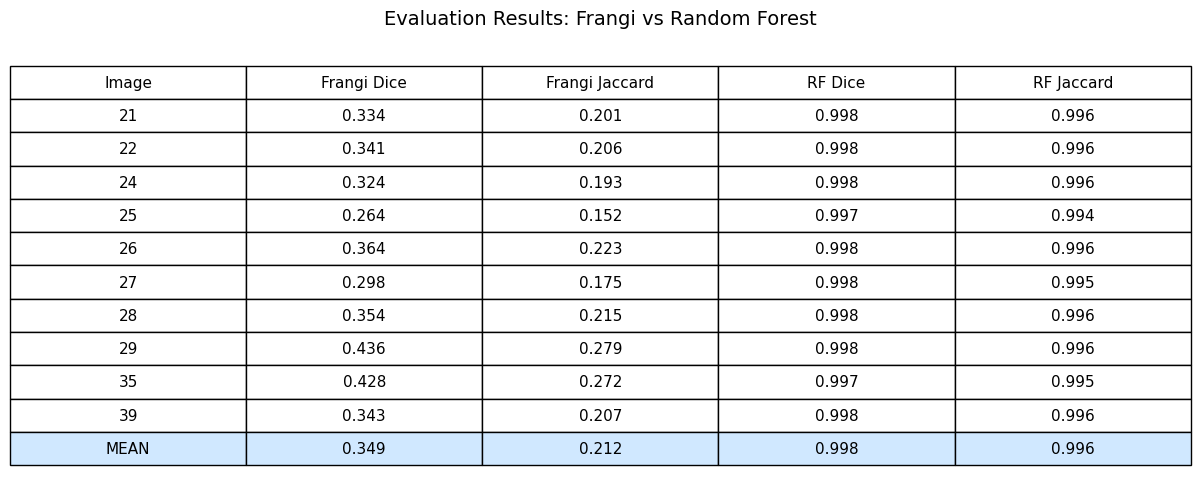

In [17]:
# Table plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
for j in range(len(df.columns)):
    table[len(df), j].set_facecolor('#d0e8ff')
plt.title('Evaluation Results: Frangi vs Random Forest', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('DRIVE/training/evaluation_table.png', dpi=150, bbox_inches='tight')
plt.show()

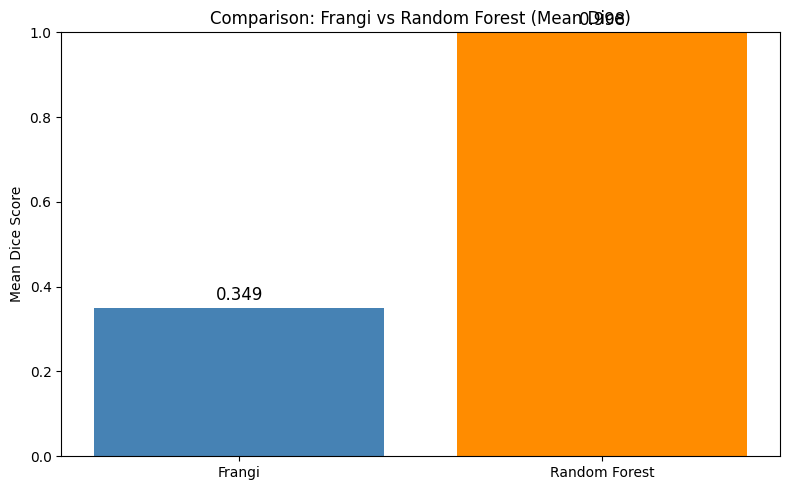

In [18]:
# Bar chart
mean_row_df = df[df['Image'] == 'MEAN']
methods = ['Frangi', 'Random Forest']
scores = [float(mean_row_df['Frangi Dice'].values[0]), float(mean_row_df['RF Dice'].values[0])]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, scores, color=['steelblue', 'darkorange'])
ax.set_ylim(0, 1)
ax.set_ylabel('Mean Dice Score')
ax.set_title('Comparison: Frangi vs Random Forest (Mean Dice)')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('DRIVE/training/evaluation_barchart.png', dpi=150)
plt.show()

In [19]:
os.makedirs('DRIVE/training/overlap_frangi', exist_ok=True)
os.makedirs('DRIVE/training/overlap_rf', exist_ok=True)


def save_overlap(original, manual, auto, title, save_path):
    """
    Saves an overlap visualization between manual and automatic segmentation.
    Green = True Positive (both agree), Red = False Negative (only in manual),
    Blue = False Positive (only in automatic).

    Args:
        original (np.ndarray): Original RGB image.
        manual (np.ndarray): Binary manual segmentation mask.
        auto (np.ndarray): Binary automatic segmentation mask.
        title (str): Title for the automatic segmentation subplot.
        save_path (str): Path to save the figure.

    Returns:
        None
    """
    overlap = np.zeros((*manual.shape, 3), dtype=np.float32)
    overlap[..., 1] = ((manual == 1) & (auto == 1)).astype(float)   # Green = TP
    overlap[..., 0] = ((manual == 1) & (auto == 0)).astype(float)   # Red   = FN
    overlap[..., 2] = ((manual == 0) & (auto == 1)).astype(float)   # Blue  = FP

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(original)
    axes[0].set_title('Original')
    axes[1].imshow(manual, cmap='gray')
    axes[1].set_title('Manual Segmentation')
    axes[2].imshow(auto, cmap='gray')
    axes[2].set_title(f'Auto Segmentation\n{title}')
    axes[3].imshow(overlap)
    axes[3].set_title('Overlap\nGreen=TP | Red=FN | Blue=FP')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f'Saved: {save_path}')


# Save all 10 images
for name in manual_segs.keys():
    base_name = name.replace('.tif', '.png')

    save_overlap(
        train_images_filtered[name],
        manual_segs[name],
        train_frangi_filtered[name],
        'Frangi',
        f'DRIVE/training/overlap_frangi/{base_name}'
    )

    save_overlap(
        train_images_filtered[name],
        manual_segs[name],
        predict_random_forest(rf_model, train_masked_filtered[name]),
        'Random Forest',
        f'DRIVE/training/overlap_rf/{base_name}'
    )

print('All overlap images saved!')

Saved: DRIVE/training/overlap_frangi/21_training.png
Saved: DRIVE/training/overlap_rf/21_training.png
Saved: DRIVE/training/overlap_frangi/22_training.png
Saved: DRIVE/training/overlap_rf/22_training.png
Saved: DRIVE/training/overlap_frangi/24_training.png
Saved: DRIVE/training/overlap_rf/24_training.png
Saved: DRIVE/training/overlap_frangi/25_training.png
Saved: DRIVE/training/overlap_rf/25_training.png
Saved: DRIVE/training/overlap_frangi/26_training.png
Saved: DRIVE/training/overlap_rf/26_training.png
Saved: DRIVE/training/overlap_frangi/27_training.png
Saved: DRIVE/training/overlap_rf/27_training.png
Saved: DRIVE/training/overlap_frangi/28_training.png
Saved: DRIVE/training/overlap_rf/28_training.png
Saved: DRIVE/training/overlap_frangi/29_training.png
Saved: DRIVE/training/overlap_rf/29_training.png
Saved: DRIVE/training/overlap_frangi/35_training.png
Saved: DRIVE/training/overlap_rf/35_training.png
Saved: DRIVE/training/overlap_frangi/39_training.png
Saved: DRIVE/training/overlap

Training hat natürlich overlapping, weil es auf diese Getestet wurden ist, deshalb auch so gute resultate iz muss ich es auf die Test daten macehn frangi und RF



In [21]:
# Manuelle Test-Segmentationen laden
manual_segs_test = load_manual_segmentations('DRIVE/test/segmentation_images')
print(f'Test manual segmentations: {len(manual_segs_test)}')

# Nur die Testbilder laden die manuelle Segmentationen haben
test_images_filtered = {name: test_images[name] for name in manual_segs_test.keys() if name in test_images}
test_preprocessed_filtered = {name: preprocess_image(img) for name, img in test_images_filtered.items()}

# Masken anwenden
test_masked_filtered = {}
for name in manual_segs_test.keys():
    mask_name = name.replace('.tif', '_mask.gif')
    mask_path = os.path.join('DRIVE/test/mask', mask_name)
    test_masked_filtered[name] = apply_mask(test_preprocessed_filtered[name], mask_path)

print(f'Test images ready: {list(test_masked_filtered.keys())}')

Test manual segmentations: 10
Test images ready: ['01_test.tif', '02_test.tif', '04_test.tif', '05_test.tif', '06_test.tif', '09_test.tif', '12_test.tif', '15_test.tif', '17_test.tif', '18_test.tif']


In [22]:
# Frangi auf Testbilder
test_frangi_filtered = {}
for name in manual_segs_test.keys():
    mask_name = name.replace('.tif', '_mask.gif')
    mask_path = os.path.join('DRIVE/test/mask', mask_name)
    binary, _ = frangi_segmentation(test_masked_filtered[name], mask_path)
    test_frangi_filtered[name] = binary
    print(f'Frangi done: {name}')

/var/folders/ll/pyzw9bhn42nch1zcwqb9gr4c0000gn/T/ipykernel_15534/52101048.py:24: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=50)


Frangi done: 01_test.tif
Frangi done: 02_test.tif
Frangi done: 04_test.tif
Frangi done: 05_test.tif
Frangi done: 06_test.tif
Frangi done: 09_test.tif
Frangi done: 12_test.tif
Frangi done: 15_test.tif
Frangi done: 17_test.tif
Frangi done: 18_test.tif


In [23]:
# Scores berechnen
test_results = []

for name in manual_segs_test.keys():
    gt = manual_segs_test[name]
    frangi_scores = evaluate_segmentation(test_frangi_filtered[name], gt)
    rf_scores = evaluate_segmentation(
        predict_random_forest(rf_model, test_masked_filtered[name]), gt)

    test_results.append({
        'Image': name.replace('_test.tif', ''),
        'Frangi Dice': round(frangi_scores['dice'], 3),
        'Frangi Jaccard': round(frangi_scores['jaccard'], 3),
        'RF Dice': round(rf_scores['dice'], 3),
        'RF Jaccard': round(rf_scores['jaccard'], 3),
    })

df_test = pd.DataFrame(test_results)
mean_row = {
    'Image': 'MEAN',
    'Frangi Dice': round(df_test['Frangi Dice'].mean(), 3),
    'Frangi Jaccard': round(df_test['Frangi Jaccard'].mean(), 3),
    'RF Dice': round(df_test['RF Dice'].mean(), 3),
    'RF Jaccard': round(df_test['RF Jaccard'].mean(), 3),
}
df_test = pd.concat([df_test, pd.DataFrame([mean_row])], ignore_index=True)
print(df_test.to_string(index=False))

Image  Frangi Dice  Frangi Jaccard  RF Dice  RF Jaccard
   01        0.418           0.264    0.545       0.374
   02        0.496           0.330    0.566       0.394
   04        0.182           0.100    0.551       0.380
   05        0.438           0.281    0.518       0.349
   06        0.254           0.145    0.524       0.355
   09        0.279           0.162    0.501       0.334
   12        0.140           0.075    0.497       0.330
   15        0.409           0.257    0.493       0.327
   17        0.183           0.101    0.478       0.314
   18        0.315           0.187    0.551       0.380
 MEAN        0.311           0.190    0.522       0.354


In [24]:
os.makedirs('DRIVE/test/overlap_frangi', exist_ok=True)
os.makedirs('DRIVE/test/overlap_rf', exist_ok=True)

for name in manual_segs_test.keys():
    base_name = name.replace('.tif', '.png')

    save_overlap(
        test_images_filtered[name],
        manual_segs_test[name],
        test_frangi_filtered[name],
        'Frangi',
        f'DRIVE/test/overlap_frangi/{base_name}'
    )

    save_overlap(
        test_images_filtered[name],
        manual_segs_test[name],
        predict_random_forest(rf_model, test_masked_filtered[name]),
        'Random Forest',
        f'DRIVE/test/overlap_rf/{base_name}'
    )

print('Alle Test Overlap Bilder gespeichert!')

Saved: DRIVE/test/overlap_frangi/01_test.png
Saved: DRIVE/test/overlap_rf/01_test.png
Saved: DRIVE/test/overlap_frangi/02_test.png
Saved: DRIVE/test/overlap_rf/02_test.png
Saved: DRIVE/test/overlap_frangi/04_test.png
Saved: DRIVE/test/overlap_rf/04_test.png
Saved: DRIVE/test/overlap_frangi/05_test.png
Saved: DRIVE/test/overlap_rf/05_test.png
Saved: DRIVE/test/overlap_frangi/06_test.png
Saved: DRIVE/test/overlap_rf/06_test.png
Saved: DRIVE/test/overlap_frangi/09_test.png
Saved: DRIVE/test/overlap_rf/09_test.png
Saved: DRIVE/test/overlap_frangi/12_test.png
Saved: DRIVE/test/overlap_rf/12_test.png
Saved: DRIVE/test/overlap_frangi/15_test.png
Saved: DRIVE/test/overlap_rf/15_test.png
Saved: DRIVE/test/overlap_frangi/17_test.png
Saved: DRIVE/test/overlap_rf/17_test.png
Saved: DRIVE/test/overlap_frangi/18_test.png
Saved: DRIVE/test/overlap_rf/18_test.png
Alle Test Overlap Bilder gespeichert!
